<Axes: xlabel='n_convenience', ylabel='price_twd_msq'>

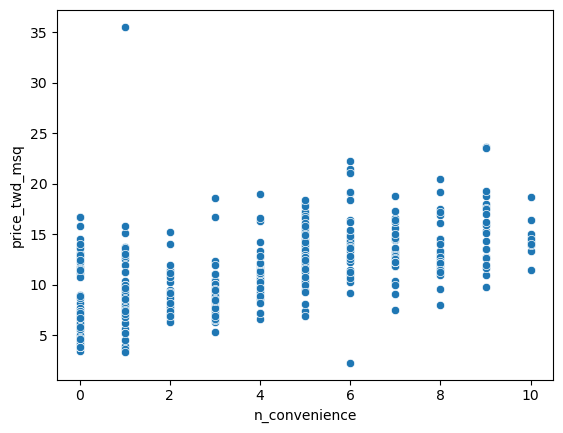

In [191]:
import pandas as pd
import seaborn as sns

taiwan_real_estate = pd.read_csv('Taiwan_real_estate2.csv')
sns.scatterplot(x = 'n_convenience', y = 'price_twd_msq', data = taiwan_real_estate)

<Axes: xlabel='n_convenience', ylabel='price_twd_msq'>

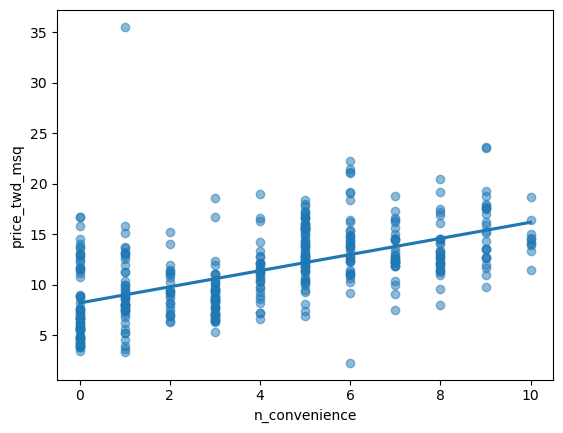

In [192]:
sns.regplot(x = 'n_convenience', y = 'price_twd_msq', data = taiwan_real_estate, ci= None, scatter_kws = {'alpha':0.5})


In [193]:
from statsmodels.formula.api import ols
swedish_motor_insurance = pd.read_csv('swedish_motor_insurance.csv')
mdl_payment_vs_claims = ols('total_payment_sek ~ n_claims', data = swedish_motor_insurance)
mdl_payment_vs_claims = mdl_payment_vs_claims.fit()
print(mdl_payment_vs_claims.params)

Intercept    19.994486
n_claims      3.413824
dtype: float64


In [194]:
# Import the ols function
from statsmodels.formula.api import ols
taiwan_real_estate = pd.read_csv('Taiwan_real_estate2.csv')
# Create the model object
mdl_price_vs_conv = ols('price_twd_msq ~ n_convenience', 
data=taiwan_real_estate)
# Fit the model
mdl_price_vs_conv = mdl_price_vs_conv.fit()
# Print the parameters of the fitted model
print(mdl_price_vs_conv.params)

Intercept        8.224237
n_convenience    0.798080
dtype: float64


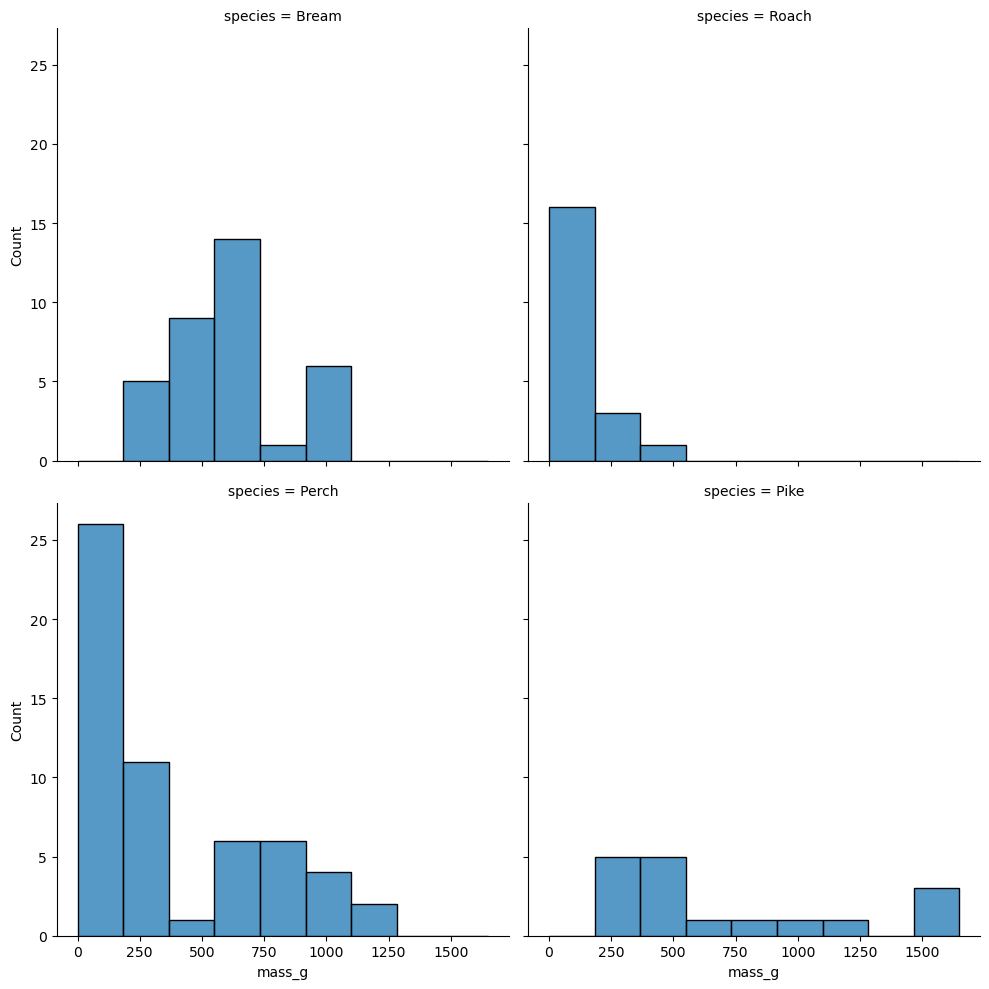

In [195]:
from matplotlib import pyplot as plt


fish = pd.read_csv('fish.csv')
sns.displot(data = fish, x = 'mass_g', col = 'species', col_wrap = 2, bins = 9)
plt.show()

In [196]:
summary_stats = fish.groupby('species')['mass_g'].mean()
print(summary_stats)

species
Bream    617.828571
Perch    382.239286
Pike     718.705882
Roach    152.050000
Name: mass_g, dtype: float64


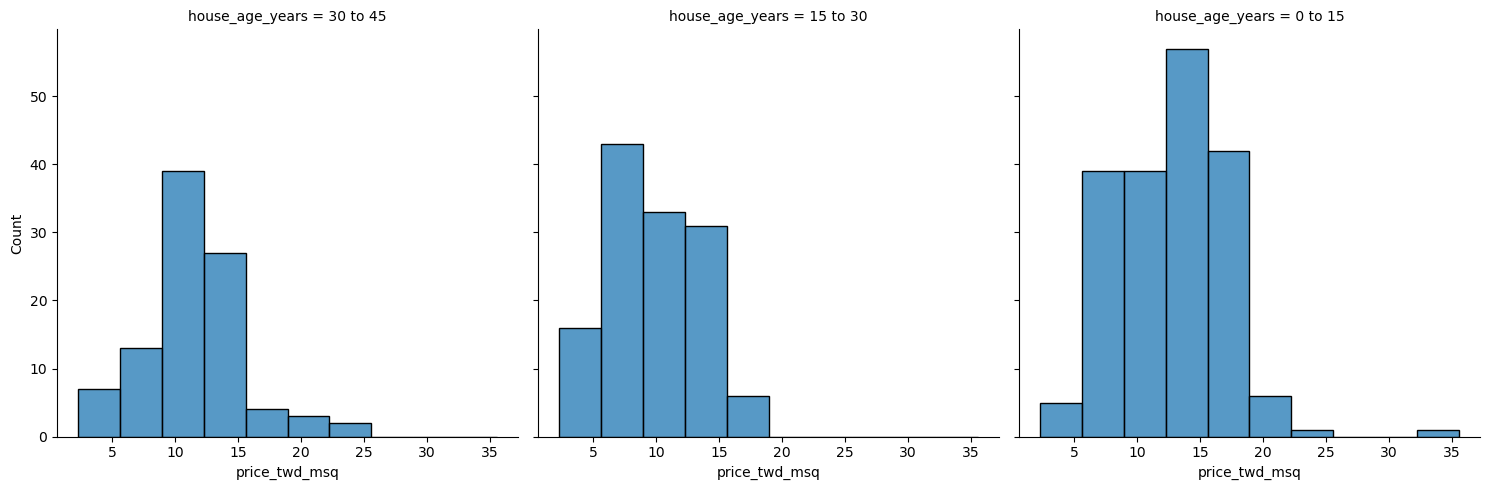

In [197]:
sns.displot(data = taiwan_real_estate, x = 'price_twd_msq', col = 'house_age_years', bins = 10)
plt.show()

In [198]:
mean_price_by_age = taiwan_real_estate.groupby('house_age_years')['price_twd_msq'].mean()
print(mean_price_by_age)

house_age_years
0 to 15     12.637471
15 to 30     9.876743
30 to 45    11.393264
Name: price_twd_msq, dtype: float64


In [199]:
mdl_price_vs_age = ols('price_twd_msq ~ house_age_years', data = taiwan_real_estate).fit()
print(mdl_price_vs_age.params)

Intercept                      12.637471
house_age_years[T.15 to 30]    -2.760728
house_age_years[T.30 to 45]    -1.244207
dtype: float64


In [200]:
mdl_price_vs_age0 = ols('price_twd_msq ~ house_age_years + 0', data = taiwan_real_estate).fit()
print(mdl_price_vs_age0.params)

house_age_years[0 to 15]     12.637471
house_age_years[15 to 30]     9.876743
house_age_years[30 to 45]    11.393264
dtype: float64


In [201]:
# Create explanatory_data 
import numpy as np


explanatory_data = pd.DataFrame({'n_convenience': np.arange(0, 11)})

print(explanatory_data)

# Use mdl_price_vs_conv to predict with explanatory_data, call it price_twd_msq
price_twd_msq = mdl_price_vs_conv.predict(explanatory_data)

print(price_twd_msq)

# Create prediction_data
prediction_data = explanatory_data.assign(
    price_twd_msq = price_twd_msq)

# Print the result
print(prediction_data)


    n_convenience
0               0
1               1
2               2
3               3
4               4
5               5
6               6
7               7
8               8
9               9
10             10
0      8.224237
1      9.022317
2      9.820397
3     10.618477
4     11.416556
5     12.214636
6     13.012716
7     13.810795
8     14.608875
9     15.406955
10    16.205035
dtype: float64
    n_convenience  price_twd_msq
0               0       8.224237
1               1       9.022317
2               2       9.820397
3               3      10.618477
4               4      11.416556
5               5      12.214636
6               6      13.012716
7               7      13.810795
8               8      14.608875
9               9      15.406955
10             10      16.205035


In [202]:
# Get the coefficients/parameters of mdl_price_vs_conv
coeffs = mdl_price_vs_conv.params

# Get the intercept (first element)
intercept = coeffs.iloc[0]

# Get the slope (second element)
slope = coeffs.iloc[1]

# Manually predict price_twd_msq using the formula
# predicted = intercept + slope * explanatory_data
manual_predictions = intercept + slope * explanatory_data['n_convenience']

print("Manual predictions:")
print(manual_predictions)
print()
print("Predictions from .predict():")
print(price_twd_msq)
print()
print("Are they equal?", (manual_predictions == price_twd_msq).all())

Manual predictions:
0      8.224237
1      9.022317
2      9.820397
3     10.618477
4     11.416556
5     12.214636
6     13.012716
7     13.810795
8     14.608875
9     15.406955
10    16.205035
Name: n_convenience, dtype: float64

Predictions from .predict():
0      8.224237
1      9.022317
2      9.820397
3     10.618477
4     11.416556
5     12.214636
6     13.012716
7     13.810795
8     14.608875
9     15.406955
10    16.205035
dtype: float64

Are they equal? True


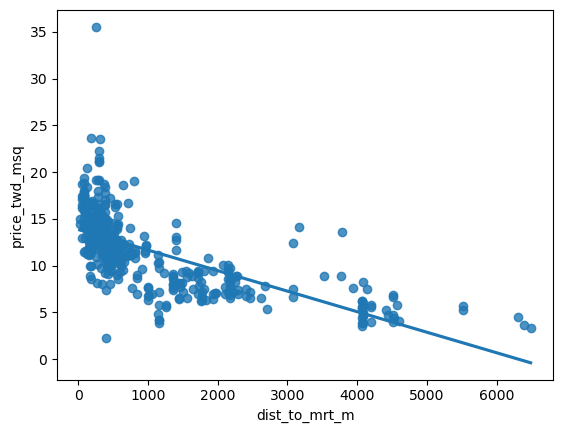

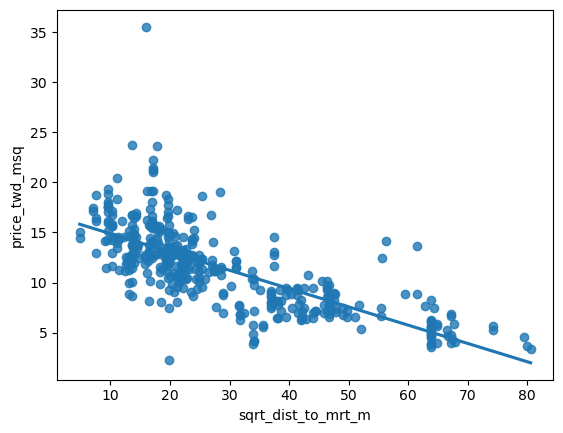

In [203]:
sns.regplot(x="dist_to_mrt_m", y="price_twd_msq", data=taiwan_real_estate, ci=None)
plt.show()

# Create sqrt_dist_to_mrt_m
taiwan_real_estate["sqrt_dist_to_mrt_m"] = np.sqrt(taiwan_real_estate["dist_to_mrt_m"])

plt.figure()

# Plot using the transformed variable
sns.regplot(x="sqrt_dist_to_mrt_m", y="price_twd_msq", data=taiwan_real_estate, ci=None)
plt.show()


In [204]:
# Run a linear regression of price_twd_msq vs. square root of dist_to_mrt_m using taiwan_real_estate
mdl_price_vs_dist = ols("price_twd_msq ~ sqrt_dist_to_mrt_m", data=taiwan_real_estate).fit()

# Print the parameters
print(mdl_price_vs_dist.params)


Intercept             16.709799
sqrt_dist_to_mrt_m    -0.182843
dtype: float64


In [205]:
explanatory_data = pd.DataFrame({"sqrt_dist_to_mrt_m": np.sqrt(np.arange(0, 81, 10) ** 2),
                                "dist_to_mrt_m": np.arange(0, 81, 10) ** 2})

# Create prediction_data by adding a column of predictions to explantory_data
prediction_data = explanatory_data.assign(
    price_twd_msq = mdl_price_vs_dist.predict(explanatory_data)
)

# Print the result
print(prediction_data)


   sqrt_dist_to_mrt_m  dist_to_mrt_m  price_twd_msq
0                 0.0              0      16.709799
1                10.0            100      14.881370
2                20.0            400      13.052942
3                30.0            900      11.224513
4                40.0           1600       9.396085
5                50.0           2500       7.567656
6                60.0           3600       5.739227
7                70.0           4900       3.910799
8                80.0           6400       2.082370


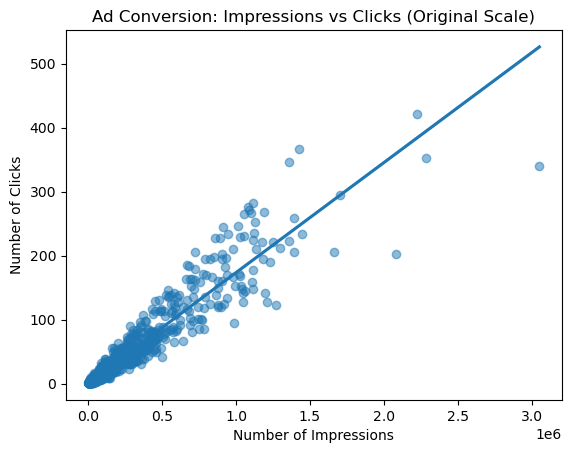

In [206]:
# Load ad_conversion data
ad_conversion = pd.read_csv('ad_conversion.csv')

# Look at the scatter plot using regplot for n_impressions vs n_clicks
sns.regplot(x='n_impressions', y='n_clicks', data=ad_conversion, ci=None, scatter_kws={'alpha': 0.5})
plt.xlabel('Number of Impressions')
plt.ylabel('Number of Clicks')
plt.title('Ad Conversion: Impressions vs Clicks (Original Scale)')
plt.show()

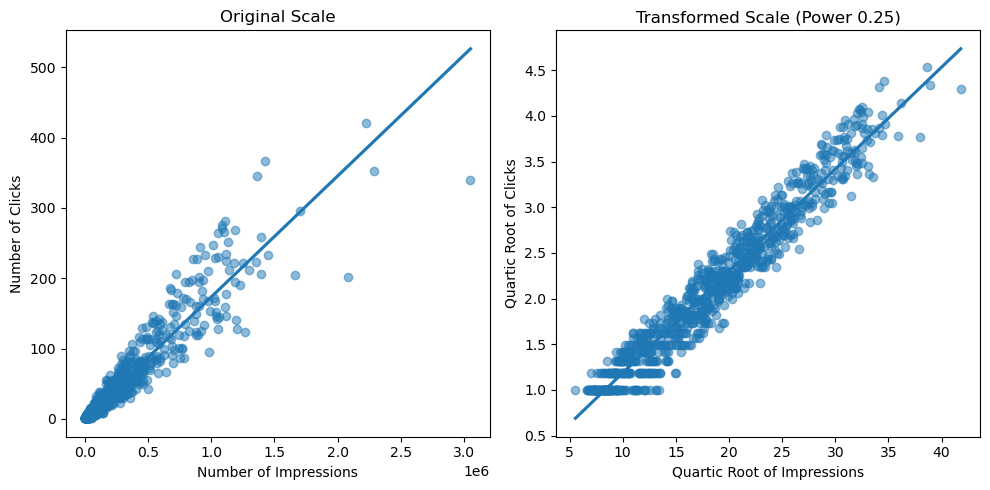

In [207]:
# Create the qdrt transformations first
ad_conversion['qdrt_n_impressions'] = ad_conversion['n_impressions'] ** 0.25
ad_conversion['qdrt_n_clicks'] = ad_conversion['n_clicks'] ** 0.25

# Create a regression plot using the transformed variables
plt.figure(figsize=(10, 5))

# Original scale plot for comparison
plt.subplot(1, 2, 1)
sns.regplot(x='n_impressions', y='n_clicks', data=ad_conversion, ci=None, scatter_kws={'alpha': 0.5})
plt.xlabel('Number of Impressions')
plt.ylabel('Number of Clicks')
plt.title('Original Scale')

# Transformed scale plot
plt.subplot(1, 2, 2)
sns.regplot(x='qdrt_n_impressions', y='qdrt_n_clicks', data=ad_conversion, ci=None, scatter_kws={'alpha': 0.5})
plt.xlabel('Quartic Root of Impressions')
plt.ylabel('Quartic Root of Clicks')
plt.title('Transformed Scale (Power 0.25)')

plt.tight_layout()
plt.show()

# The points on the transformed plot track the line more closely!

In [208]:
# Display the first few rows to verify the transformations
print(ad_conversion[['n_impressions', 'n_clicks', 'qdrt_n_impressions', 'qdrt_n_clicks']].head())

   n_impressions  n_clicks  qdrt_n_impressions  qdrt_n_clicks
0           7350         1            9.259165       1.000000
1          17861         2           11.560495       1.189207
2           4259         1            8.078429       1.000000
3           4133         1            8.018006       1.000000
4          15615         3           11.178551       1.316074


In [209]:
# Run a linear regression of qdrt_n_clicks versus qdrt_n_impressions using ad_conversion
mdl_click_vs_impression = ols('qdrt_n_clicks ~ qdrt_n_impressions', data=ad_conversion).fit()

# Print the model parameters
print(mdl_click_vs_impression.params)

Intercept             0.071748
qdrt_n_impressions    0.111533
dtype: float64


In [210]:
# Create explanatory data for predictions
# qdrt_n_impressions (for a range of 0 to 3000000, with a step of 500000) raised to a power of 0.25
# Also have n_impressions as a reference (no need to raise a power)
explanatory_data = pd.DataFrame({
    'n_impressions': np.arange(0, 3000001, 500000),
    'qdrt_n_impressions': np.arange(0, 3000001, 500000) ** 0.25
})

# Print explanatory data
print("Explanatory data:")
print(explanatory_data)
print()

# Then predict data for qdrt_n_clicks and assign it to prediction_data
prediction_data = explanatory_data.assign(
    qdrt_n_clicks = mdl_click_vs_impression.predict(explanatory_data)
)

# Print the prediction data
print("Prediction data:")
print(prediction_data)

Explanatory data:
   n_impressions  qdrt_n_impressions
0              0            0.000000
1         500000           26.591479
2        1000000           31.622777
3        1500000           34.996355
4        2000000           37.606031
5        2500000           39.763536
6        3000000           41.617915

Prediction data:
   n_impressions  qdrt_n_impressions  qdrt_n_clicks
0              0            0.000000       0.071748
1         500000           26.591479       3.037576
2        1000000           31.622777       3.598732
3        1500000           34.996355       3.974998
4        2000000           37.606031       4.266063
5        2500000           39.763536       4.506696
6        3000000           41.617915       4.713520


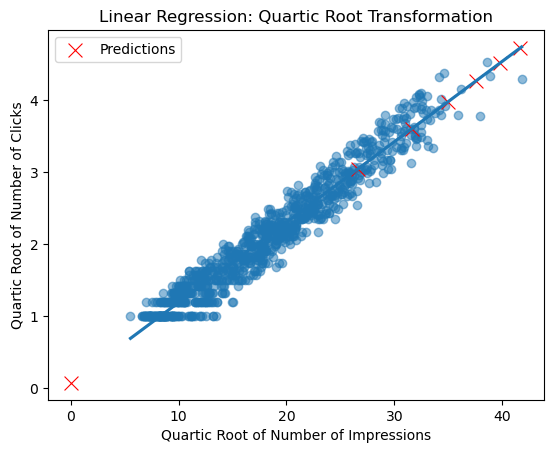

In [211]:
# Do scatter plot (using regplot) and add a layer of prediction points
sns.regplot(x='qdrt_n_impressions', y='qdrt_n_clicks', data=ad_conversion, 
            ci=None, scatter_kws={'alpha': 0.5})

# Add a layer of prediction points
sns.scatterplot(x='qdrt_n_impressions', y='qdrt_n_clicks', data=prediction_data, 
                color='red', label='Predictions', s=100, marker='x')

plt.xlabel('Quartic Root of Number of Impressions')
plt.ylabel('Quartic Root of Number of Clicks')
plt.title('Linear Regression: Quartic Root Transformation')
plt.legend()
plt.show()

In [212]:
# Back-transformation: From prediction_data, create n_clicks by raising qdrt_n_clicks to a power of 4
prediction_data['n_clicks'] = prediction_data['qdrt_n_clicks'] ** 4

# Print the updated prediction_data with back-transformed values
print("Prediction data with back-transformed n_clicks:")
print(prediction_data)

Prediction data with back-transformed n_clicks:
   n_impressions  qdrt_n_impressions  qdrt_n_clicks    n_clicks
0              0            0.000000       0.071748    0.000026
1         500000           26.591479       3.037576   85.135121
2        1000000           31.622777       3.598732  167.725102
3        1500000           34.996355       3.974998  249.659131
4        2000000           37.606031       4.266063  331.214159
5        2500000           39.763536       4.506696  412.508546
6        3000000           41.617915       4.713520  493.607180


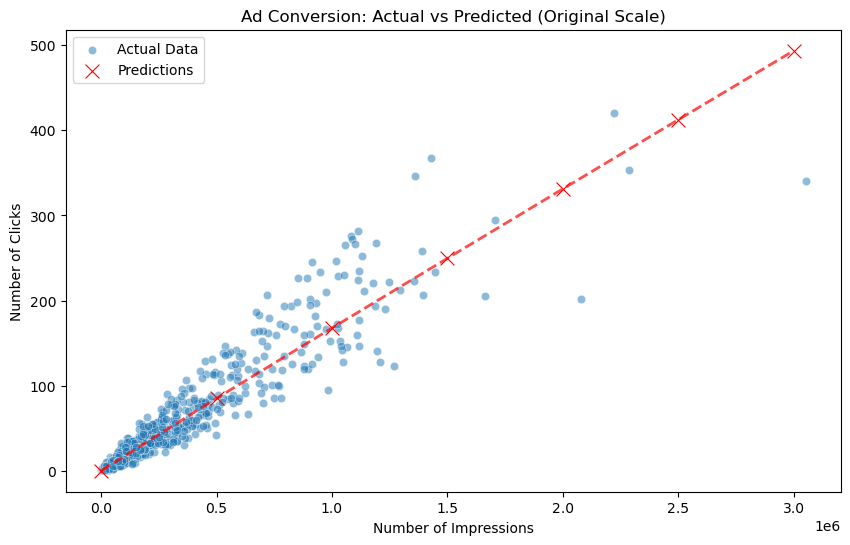

In [213]:
# Edit the plot to add a layer of points from prediction_data (n_impressions vs. n_clicks), colored red
plt.figure(figsize=(10, 6))

# Original data scatter plot
sns.scatterplot(x='n_impressions', y='n_clicks', data=ad_conversion, alpha=0.5, label='Actual Data')

# Add prediction points (back-transformed to original scale)
sns.scatterplot(x='n_impressions', y='n_clicks', data=prediction_data, 
                color='red', s=100, label='Predictions', marker='x')

# Add prediction line using all prediction points
plt.plot(prediction_data['n_impressions'], prediction_data['n_clicks'], 
         color='red', linestyle='--', linewidth=2, alpha=0.7)

plt.xlabel('Number of Impressions')
plt.ylabel('Number of Clicks')
plt.title('Ad Conversion: Actual vs Predicted (Original Scale)')
plt.legend()
plt.show()

In [214]:
# Determine whether this model is a good fit
print("Model Summary:")
print(mdl_click_vs_impression.summary())
print()

# Get R-squared and Adjusted R-squared
r_squared = mdl_click_vs_impression.rsquared
adj_r_squared = mdl_click_vs_impression.rsquared_adj

print(f"R-squared: {r_squared:.4f}")
print(f"Adjusted R-squared: {adj_r_squared:.4f}")
print()

# Interpretation
if r_squared > 0.7:
    fit_quality = "GOOD"
elif r_squared > 0.5:
    fit_quality = "MODERATE"
else:
    fit_quality = "POOR"
    
print(f"Model Fit Quality: {fit_quality}")
print(f"The model explains {r_squared * 100:.2f}% of the variance in quartic root of clicks.")

Model Summary:
                            OLS Regression Results                            
Dep. Variable:          qdrt_n_clicks   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                 1.590e+04
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:28:46   Log-Likelihood:                 193.90
No. Observations:                 936   AIC:                            -383.8
Df Residuals:                     934   BIC:                            -374.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            

In [215]:
# Determine RSE (Residual Standard Error) and interpret the result
# RSE = sqrt(RSS / degrees_of_freedom)
# RSS = Residual Sum of Squares
# degrees_of_freedom = n - p - 1 (where p = number of predictors, n = sample size)

# Get model metrics
n = len(ad_conversion)  # sample size
p = 1  # number of predictors (qdrt_n_impressions)
df_residuals = n - p - 1  # degrees of freedom for residuals

# Get MSE (Mean Squared Error) from the model - this is equivalent to RSE^2
mse = mdl_click_vs_impression.mse_resid
rse = mse ** 0.5  # RSE is sqrt of MSE

print(f"Sample size (n): {n}")
print(f"Number of predictors (p): {p}")
print(f"Degrees of freedom (n - p - 1): {df_residuals}")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Residual Standard Error (RSE): {rse:.6f}")
print()

# Calculate RSE as a percentage of the mean of qdrt_n_clicks
mean_qdrt_clicks = ad_conversion['qdrt_n_clicks'].mean()
rse_percentage = (rse / mean_qdrt_clicks) * 100

print(f"Mean of qdrt_n_clicks: {mean_qdrt_clicks:.4f}")
print(f"RSE as percentage of mean: {rse_percentage:.2f}%")
print()

# Interpretation
print("INTERPRETATION:")
print(f"The RSE of {rse:.4f} means that the typical prediction error for the quartic root of clicks is about {rse:.4f} units.")
print(f"In terms of percentage, this is about {rse_percentage:.1f}% of the mean quartic root of clicks.")
print()
print("A lower RSE indicates better model fit. The RSE should be compared to:")
print("  - The scale of the response variable (qdrt_n_clicks)")
print("  - The RSE of alternative models for model selection")
print()
print("Note: When back-transforming to original scale (n_clicks), the prediction") 
print("uncertainty increases due to the power transformation.")

Sample size (n): 936
Number of predictors (p): 1
Degrees of freedom (n - p - 1): 934
Mean Squared Error (MSE): 0.038772
Residual Standard Error (RSE): 0.196906

Mean of qdrt_n_clicks: 2.0835
RSE as percentage of mean: 9.45%

INTERPRETATION:
The RSE of 0.1969 means that the typical prediction error for the quartic root of clicks is about 0.1969 units.
In terms of percentage, this is about 9.5% of the mean quartic root of clicks.

A lower RSE indicates better model fit. The RSE should be compared to:
  - The scale of the response variable (qdrt_n_clicks)
  - The RSE of alternative models for model selection

Note: When back-transforming to original scale (n_clicks), the prediction
uncertainty increases due to the power transformation.
